# WDR91 DEL — Model Training & Evaluation

**Goal:** Train and compare XGBoost and LightGBM classifiers on combined fingerprints (ECFP6 + MACCS + RDK) from the DEL screen.

**Primary metric:** Enrichment Factor @1% (EF@1%)

**Split strategy:** Stratified 80/20 train/test split.

**Features:** ECFP6 (2048) + MACCS (167) + RDK (2048) = **4263 bits** per compound

---
**Before running:** Upload `WDR91.parquet` to `My Drive/CS502/data/WDR91.parquet`

In [1]:
!pip install xgboost lightgbm pyarrow tqdm seaborn -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH      = '/content/drive/MyDrive/CS502/data/WDR91.parquet'
XGB_MODEL_PATH = '/content/drive/MyDrive/CS502/models/xgb_multifp.json'
LGB_MODEL_PATH = '/content/drive/MyDrive/CS502/models/lgbm_multifp.txt'

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from pathlib import Path
from tqdm import tqdm

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

Path('/content/drive/MyDrive/CS502/models').mkdir(parents=True, exist_ok=True)

## Helper Functions

In [4]:
FP_DIMS = {
    'ECFP4': 2048, 'ECFP6': 2048, 'FCFP4': 2048, 'FCFP6': 2048,
    'MACCS': 167, 'RDK': 2048, 'AVALON': 512, 'ATOMPAIR': 2048, 'TOPTOR': 2048,
}

SCALAR_COLS = [
    'COMPOUND_ID', 'LIBRARY_ID', 'BB1_ID', 'BB2_ID', 'BB3_ID',
    'TARGET_VALUE', 'LABEL', 'MW', 'ALOGP'
]

FP_NAMES = ['ECFP6', 'MACCS', 'RDK']


def indices_to_sparse(index_lists, n_bits):
    rows, cols = [], []
    for i, bits in enumerate(index_lists):
        for b in bits:
            if b < n_bits:
                rows.append(i)
                cols.append(b)
    data = np.ones(len(rows), dtype=np.uint8)
    return sp.csr_matrix((data, (rows, cols)), shape=(len(index_lists), n_bits))


def load_multi_fingerprints(path, fp_names=FP_NAMES, batch_size=50_000):
    pf = pq.ParquetFile(path)
    scalar_frames = []
    fp_batches = {fp: [] for fp in fp_names}

    for batch in tqdm(pf.iter_batches(batch_size=batch_size, columns=SCALAR_COLS + fp_names),
                      desc='Loading fingerprints'):
        batch_df = batch.to_pandas()
        scalar_frames.append(batch_df[SCALAR_COLS])
        for fp in fp_names:
            fp_batches[fp].append(indices_to_sparse(batch_df[fp].tolist(), FP_DIMS[fp]))

    fp_matrices = [sp.vstack(fp_batches[fp], format='csr') for fp in fp_names]
    X = sp.hstack(fp_matrices, format='csr')
    df = pd.concat(scalar_frames, ignore_index=True)
    total_bits = sum(FP_DIMS[fp] for fp in fp_names)
    print(f'Combined feature matrix: {X.shape}  ({total_bits} bits from {fp_names})')
    return X, df


def enrichment_factor(y_true, y_score, frac=0.01):
    n = len(y_true)
    n_top = max(1, int(n * frac))
    top_idx = np.argsort(y_score)[::-1][:n_top]
    hits_in_top = y_true[top_idx].sum()
    total_hits = y_true.sum()
    if total_hits == 0:
        return 0.0
    return (hits_in_top / n_top) / (total_hits / n)


def evaluate(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
        'PR-AUC':    average_precision_score(y_true, y_prob),
        'Bal. Acc.': balanced_accuracy_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'EF@1%':     enrichment_factor(y_true, y_prob, 0.01),
        'EF@5%':     enrichment_factor(y_true, y_prob, 0.05),
    }

## 1. Load Data

In [5]:
print(f'Loading fingerprints: {FP_NAMES} ...')
X, df = load_multi_fingerprints(DATA_PATH)

y = df['LABEL'].values

print(f'\nX shape : {X.shape}')
print(f'Hits    : {y.sum():,} / {len(y):,} ({100*y.mean():.2f}%)')

Loading fingerprints: ['ECFP6', 'MACCS', 'RDK'] ...


Loading fingerprints: 8it [06:33, 49.17s/it]

Combined feature matrix: (375595, 4263)  (4263 bits from ['ECFP6', 'MACCS', 'RDK'])

X shape : (375595, 4263)
Hits    : 28,778 / 375,595 (7.66%)


## 2. Stratified 80/20 Train/Test Split

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_tr_f32 = X_tr.astype(np.float32)
X_te_f32 = X_te.astype(np.float32)

SPW = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'Train : {X_tr.shape[0]:,} compounds  ({y_tr.sum():,} hits, {100*y_tr.mean():.2f}%)')
print(f'Test  : {X_te.shape[0]:,} compounds  ({y_te.sum():,} hits, {100*y_te.mean():.2f}%)')
print(f'scale_pos_weight = {SPW:.2f}')

Train : 300,476 compounds  (23,022 hits, 7.66%)
Test  : 75,119 compounds  (5,756 hits, 7.66%)
scale_pos_weight = 12.05


## 3. Train XGBoost

In [7]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=SPW,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_tr_f32, y_tr)
print('XGBoost training complete.')

XGBoost training complete.


## 4. Train LightGBM

In [8]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=SPW,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
lgb_model.fit(X_tr_f32, y_tr)
print('LightGBM training complete.')

LightGBM training complete.


## 5. Compare Results

In [9]:
xgb_prob = xgb_model.predict_proba(X_te_f32)[:, 1]
lgb_prob = lgb_model.predict_proba(X_te_f32)[:, 1]

fp_label = '+'.join(FP_NAMES)
results_df = pd.DataFrame([
    {'Features': fp_label, 'Model': 'XGBoost',  **evaluate(y_te, xgb_prob)},
    {'Features': fp_label, 'Model': 'LightGBM', **evaluate(y_te, lgb_prob)},
])

print('\n=== Test Set Results ===')
print(results_df.to_string(index=False))


=== Test Set Results ===
       Features    Model  ROC-AUC   PR-AUC  Bal. Acc.   Recall    EF@1%    EF@5%
ECFP6+MACCS+RDK  XGBoost 0.740289 0.256467   0.669962 0.646630 7.976305 4.340917
ECFP6+MACCS+RDK LightGBM 0.732602 0.243959   0.663137 0.653926 7.837285 4.163666


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 6. Baseline & Enhanced Configurations (ECFP4 / All 9 FPs)

In [10]:
from sklearn.linear_model import LogisticRegression

ALL_9_FPS = ['ECFP4', 'ECFP6', 'FCFP4', 'FCFP6', 'MACCS', 'RDK', 'AVALON', 'ATOMPAIR', 'TOPTOR']

def run_config(fp_names, label):
    """Load fingerprints, train LightGBM + LogReg on 80/20 split, return result rows."""
    print(f'\n--- {label} ({len(fp_names)} FP(s)) ---')
    X_cfg, df_cfg = load_multi_fingerprints(DATA_PATH, fp_names=fp_names)
    y_cfg = df_cfg['LABEL'].values
    X_tr_, X_te_, y_tr_, y_te_ = train_test_split(
        X_cfg, y_cfg, test_size=0.2, stratify=y_cfg, random_state=42
    )
    X_tr_f = X_tr_.astype(np.float32)
    X_te_f = X_te_.astype(np.float32)
    spw = (y_tr_ == 0).sum() / (y_tr_ == 1).sum()

    rows = []

    # LightGBM
    lgb_m = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
        random_state=42, n_jobs=-1, verbosity=-1,
    )
    lgb_m.fit(X_tr_f, y_tr_)
    prob_lgb = lgb_m.predict_proba(X_te_f)[:, 1]
    print(f'  LightGBM  ROC-AUC: {roc_auc_score(y_te_, prob_lgb):.4f}')
    rows.append({'Features': label, 'Model': 'LightGBM', **evaluate(y_te_, prob_lgb)})

    # Logistic Regression
    lr_m = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    lr_m.fit(X_tr_f, y_tr_)
    prob_lr = lr_m.predict_proba(X_te_f)[:, 1]
    print(f'  LogReg    ROC-AUC: {roc_auc_score(y_te_, prob_lr):.4f}')
    rows.append({'Features': label, 'Model': 'LogReg', **evaluate(y_te_, prob_lr)})

    return rows

extra_rows = []
extra_rows += run_config(['ECFP4'], 'ECFP4')
extra_rows += run_config(ALL_9_FPS, 'All 9 FPs')
extra_df = pd.DataFrame(extra_rows)
print('\n=== Baseline & Enhanced Results ===')
print(extra_df.to_string(index=False))


--- ECFP4 (1 FP(s)) ---


Loading fingerprints: 8it [03:06, 23.34s/it]


Combined feature matrix: (375595, 2048)  (2048 bits from ['ECFP4'])
  LightGBM  ROC-AUC: 0.7189


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LogReg    ROC-AUC: 0.6333

--- All 9 FPs (9 FP(s)) ---


Loading fingerprints: 8it [25:03, 187.98s/it]


Combined feature matrix: (375595, 15015)  (15015 bits from ['ECFP4', 'ECFP6', 'FCFP4', 'FCFP6', 'MACCS', 'RDK', 'AVALON', 'ATOMPAIR', 'TOPTOR'])
  LightGBM  ROC-AUC: 0.8745


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LogReg    ROC-AUC: 0.7554

=== Baseline & Enhanced Results ===
 Features    Model  ROC-AUC   PR-AUC  Bal. Acc.   Recall     EF@1%    EF@5%
    ECFP4 LightGBM 0.718883 0.227212   0.651592 0.628214  7.142182 3.993366
    ECFP4   LogReg 0.633271 0.121960   0.593645 0.591209  2.728279 2.203476
All 9 FPs LightGBM 0.874511 0.533446   0.793543 0.762856 11.903636 8.163983
All 9 FPs   LogReg 0.755439 0.200306   0.691514 0.694232  4.153240 3.551976


## 7. Full Results Table (All 6 Configurations)

In [11]:
fp_label = '+'.join(FP_NAMES)
xgb_prob = xgb_model.predict_proba(X_te_f32)[:, 1]
lgb_prob = lgb_model.predict_proba(X_te_f32)[:, 1]

primary_rows = [
    {'Features': fp_label, 'Model': 'LightGBM', **evaluate(y_te, lgb_prob)},
    {'Features': fp_label, 'Model': 'XGBoost',  **evaluate(y_te, xgb_prob)},
]

all_results = pd.DataFrame(extra_rows + primary_rows)
col_order = ['Features', 'Model', 'ROC-AUC', 'PR-AUC', 'Bal. Acc.', 'Recall', 'EF@1%', 'EF@5%']
all_results = all_results[col_order]

print('\n=== Full Results — All 6 Configurations ===')
print(all_results.to_string(index=False))


=== Full Results — All 6 Configurations ===
       Features    Model  ROC-AUC   PR-AUC  Bal. Acc.   Recall     EF@1%    EF@5%
          ECFP4 LightGBM 0.718883 0.227212   0.651592 0.628214  7.142182 3.993366
          ECFP4   LogReg 0.633271 0.121960   0.593645 0.591209  2.728279 2.203476
      All 9 FPs LightGBM 0.874511 0.533446   0.793543 0.762856 11.903636 8.163983
      All 9 FPs   LogReg 0.755439 0.200306   0.691514 0.694232  4.153240 3.551976
ECFP6+MACCS+RDK LightGBM 0.732602 0.243959   0.663137 0.653926  7.837285 4.163666
ECFP6+MACCS+RDK  XGBoost 0.740289 0.256467   0.669962 0.646630  7.976305 4.340917


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 6. ROC & Precision-Recall Curves

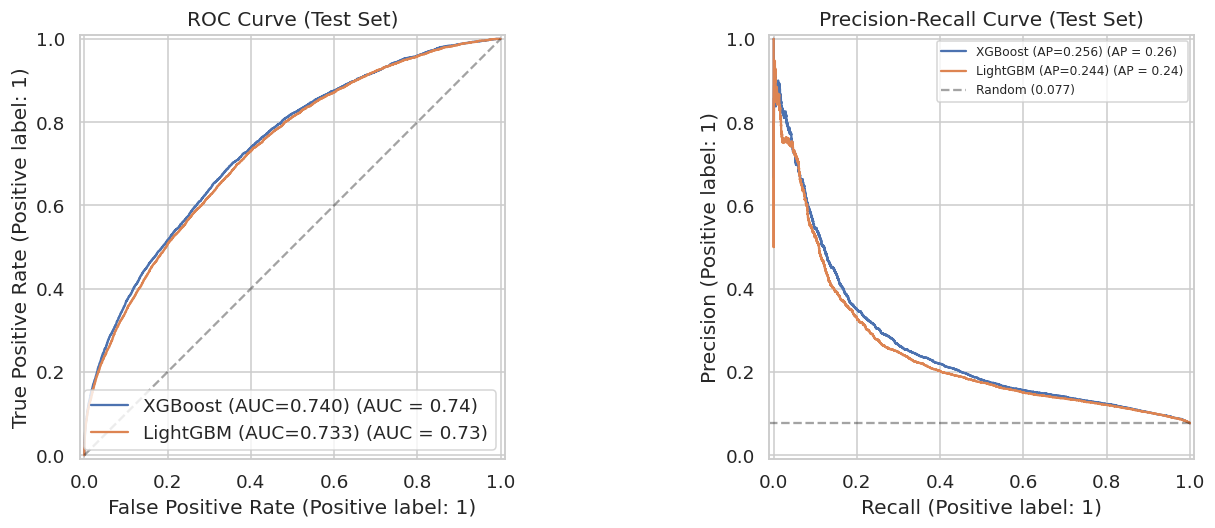

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for prob, name, color in [
    (xgb_prob, 'XGBoost',  'coral'),
    (lgb_prob, 'LightGBM', 'steelblue'),
]:
    RocCurveDisplay.from_predictions(y_te, prob, ax=axes[0],
        name=f'{name} (AUC={roc_auc_score(y_te, prob):.3f})')
    PrecisionRecallDisplay.from_predictions(y_te, prob, ax=axes[1],
        name=f'{name} (AP={average_precision_score(y_te, prob):.3f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curve (Test Set)')
axes[1].axhline(y_te.mean(), color='k', linestyle='--', alpha=0.4,
                label=f'Random ({y_te.mean():.3f})')
axes[1].legend(fontsize=8)
axes[1].set_title('Precision-Recall Curve (Test Set)')

plt.tight_layout()
plt.show()

## 7. Enrichment Factor Curves

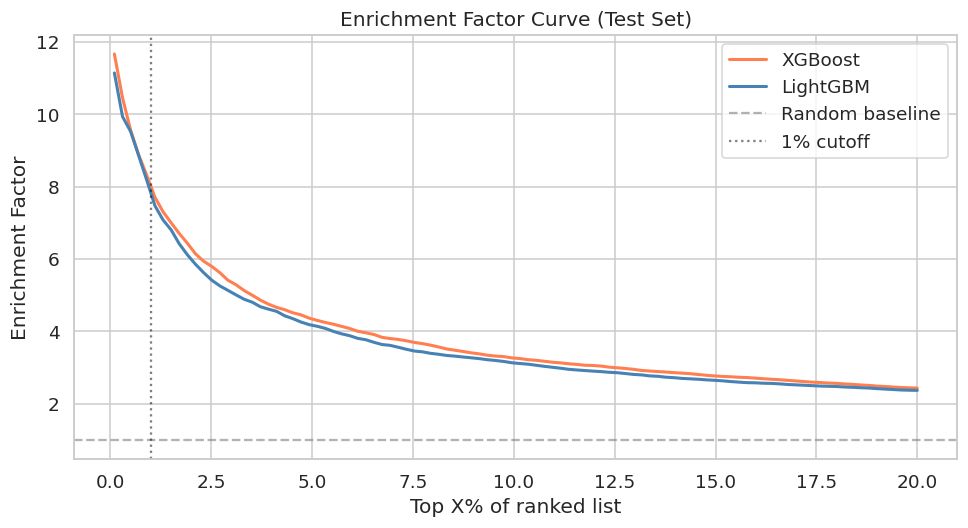


                        XGBoost   LightGBM
EF @0.1%                11.66      11.14
EF @0.5%                 9.54       9.54
EF @1%                   7.98       7.84
EF @5%                   4.34       4.16


In [13]:
fractions = np.linspace(0.001, 0.20, 100)

fig, ax = plt.subplots(figsize=(9, 5))
for prob, name, color in [
    (xgb_prob, 'XGBoost',  'coral'),
    (lgb_prob, 'LightGBM', 'steelblue'),
]:
    efs = [enrichment_factor(y_te, prob, f) for f in fractions]
    ax.plot(fractions * 100, efs, lw=2, color=color, label=name)

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.6, label='Random baseline')
ax.axvline(1.0, color='black', linestyle=':', alpha=0.5, label='1% cutoff')
ax.set_xlabel('Top X% of ranked list')
ax.set_ylabel('Enrichment Factor')
ax.set_title('Enrichment Factor Curve (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n{"":20s} {"XGBoost":>10s} {"LightGBM":>10s}')
for frac, label in [(0.001,'0.1%'),(0.005,'0.5%'),(0.01,'1%'),(0.05,'5%')]:
    ef_xgb = enrichment_factor(y_te, xgb_prob, frac)
    ef_lgb = enrichment_factor(y_te, lgb_prob, frac)
    print(f'EF @{label:4s}           {ef_xgb:>10.2f} {ef_lgb:>10.2f}')

## 8. Train Final Models on Full Data & Save

In [14]:
SPW_full = (y == 0).sum() / (y == 1).sum()
X_full = X.astype(np.float32)

print('Training final XGBoost on full dataset...')
final_xgb = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SPW_full,
    eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0,
)
final_xgb.fit(X_full, y)
final_xgb.save_model(XGB_MODEL_PATH)
print(f'XGBoost saved to {XGB_MODEL_PATH}')

print('\nTraining final LightGBM on full dataset...')
final_lgb = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SPW_full,
    random_state=42, n_jobs=-1, verbosity=-1,
)
final_lgb.fit(X_full, y)
final_lgb.booster_.save_model(LGB_MODEL_PATH)
print(f'LightGBM saved to {LGB_MODEL_PATH}')

Training final XGBoost on full dataset...
XGBoost saved to /content/drive/MyDrive/CS502/models/xgb_multifp.json

Training final LightGBM on full dataset...
LightGBM saved to /content/drive/MyDrive/CS502/models/lgbm_multifp.txt


## 9. Feature Importance by Fingerprint Block (XGBoost)

Feature importance by fingerprint block (XGBoost):
  ECFP6   : 0.8626  (86.3%)
  MACCS   : 0.0998  (10.0%)
  RDK     : 0.0376  (3.8%)


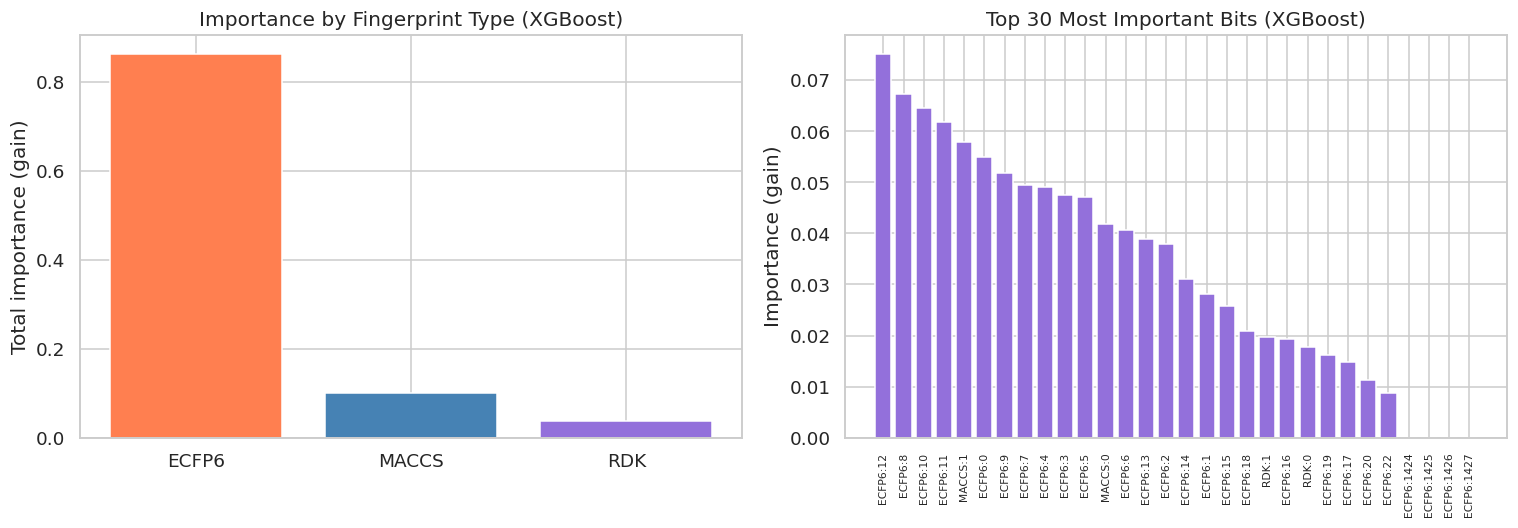

In [15]:
importance = final_xgb.feature_importances_
boundaries = np.cumsum([0] + [FP_DIMS[fp] for fp in FP_NAMES])

fp_importance = {}
for i, fp in enumerate(FP_NAMES):
    fp_importance[fp] = importance[boundaries[i]:boundaries[i+1]].sum()

total_imp = sum(fp_importance.values())
print('Feature importance by fingerprint block (XGBoost):')
for fp, imp in fp_importance.items():
    print(f'  {fp:8s}: {imp:.4f}  ({100*imp/total_imp:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fp_importance.keys(), fp_importance.values(),
            color=['coral', 'steelblue', 'mediumpurple'])
axes[0].set_ylabel('Total importance (gain)')
axes[0].set_title('Importance by Fingerprint Type (XGBoost)')

top_n = 30
top_idx = np.argsort(importance)[::-1][:top_n]
bit_labels = []
for idx in top_idx:
    for i, fp in enumerate(FP_NAMES):
        if boundaries[i] <= idx < boundaries[i+1]:
            bit_labels.append(f'{fp}:{idx - boundaries[i]}')
            break

axes[1].bar(range(top_n), importance[top_idx], color='mediumpurple')
axes[1].set_xticks(range(top_n))
axes[1].set_xticklabels(bit_labels, rotation=90, fontsize=7)
axes[1].set_ylabel('Importance (gain)')
axes[1].set_title(f'Top {top_n} Most Important Bits (XGBoost)')

plt.tight_layout()
plt.show()